In [1]:
import glob
from gplately import pygplates
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import pygmt
import scipy
import shutil
import sys
import xarray as xr

In [ ]:
ages = list(np.arange(0,260,10)) # Ages that we simulated temperature for
var = 'puma_temperature_surface_air' #variable name to get aves from (probably air temp)

colours = ['plum','lightblue','salmon','yellowgreen','blue','red','green','cyan','orange','pink']

# Scotese (2021) paleotemperature data (from publication's supplementary data)
scoteseVar = pd.ExcelFile('/Users/jono/Documents/Databases/scotese2021_paleotemps/Part 4. Phanerozoic_Paleotemperature_Summaryv4.xlsx')
scoteseVar = pd.read_excel(scoteseVar, '1my version') # Read the specific sheet 


# Get the paths to the climate models
model_path = '/Users/jono/OneDrive - The University of Sydney (Staff)/paleoReef/climateModelData_OGnorealign'
co2s=['100','200','280','560','1120','2240','4480','fosterCO2']
models=[]
for co2 in co2s:
    model = os.path.join(model_path,f'2024-07-23_earthbyte_paleo_PaleomagRef_{co2}')
    # model = os.path.join(model_path,f'2024-10-08_scotese_paleo_{co2}ppm_shallowSea_{co2}')

    models.append(model)

In [3]:
# Filter Scotese data for simulated ages and create a dataframe
df = scoteseVar[scoteseVar['Age'].isin(ages)][['Age', 'GAT']].set_index('Age').rename(columns={'GAT': 'Scotese'})


In [7]:
# Add the GMST for each model run
for i in range(len(models)):
    model = models[i]
    co2 = co2s[i]
    for age in ages:
        plasimGrid = f'{model}/{str(age)}Ma_nc_outputs/3000-12-30_plasim.nc'

        if not os.path.exists(plasimGrid):
            print(f'{plasimGrid} does not exist, continuing but this may not work')
            continue

        info = pygmt.grdinfo(grid=f'{plasimGrid}?{var}', per_column=True, force_scan='2')

        mean = round(float(info.split()[10]), 4)

        df.at[age,co2] = mean

df

grdinfo [WARNING]: The step size of coordinate (latitude) in grid /Users/jono/OneDrive - The University of Sydney (Staff)/paleoReef/climateModelData_OGnorealign/2024-07-23_earthbyte_paleo_PaleomagRef_100/0Ma_nc_outputs/3000-12-30_plasim.nc is not constant.
grdinfo [WARNING]: GMT will use a constant step size of -5.53294; the original ranges from -5.53781 to -5.49181.
grdinfo [WARNING]: Guessing of registration in conflict between x and y, using gridline
grdinfo [WARNING]: The step size of coordinate (latitude) in grid /Users/jono/OneDrive - The University of Sydney (Staff)/paleoReef/climateModelData_OGnorealign/2024-07-23_earthbyte_paleo_PaleomagRef_100/10Ma_nc_outputs/3000-12-30_plasim.nc is not constant.
grdinfo [WARNING]: GMT will use a constant step size of -5.53294; the original ranges from -5.53781 to -5.49181.
grdinfo [WARNING]: Guessing of registration in conflict between x and y, using gridline
grdinfo [WARNING]: The step size of coordinate (latitude) in grid /Users/jono/OneDr

/Users/jono/OneDrive - The University of Sydney (Staff)/paleoReef/climateModelData_OGnorealign/2024-07-23_earthbyte_paleo_PaleomagRef_100/50Ma_nc_outputs/3000-12-30_plasim.nc does not exist, continuing but this may not work
/Users/jono/OneDrive - The University of Sydney (Staff)/paleoReef/climateModelData_OGnorealign/2024-07-23_earthbyte_paleo_PaleomagRef_100/90Ma_nc_outputs/3000-12-30_plasim.nc does not exist, continuing but this may not work
/Users/jono/OneDrive - The University of Sydney (Staff)/paleoReef/climateModelData_OGnorealign/2024-07-23_earthbyte_paleo_PaleomagRef_100/100Ma_nc_outputs/3000-12-30_plasim.nc does not exist, continuing but this may not work
/Users/jono/OneDrive - The University of Sydney (Staff)/paleoReef/climateModelData_OGnorealign/2024-07-23_earthbyte_paleo_PaleomagRef_100/110Ma_nc_outputs/3000-12-30_plasim.nc does not exist, continuing but this may not work
/Users/jono/OneDrive - The University of Sydney (Staff)/paleoReef/climateModelData_OGnorealign/2024-07

grdinfo [WARNING]: Guessing of registration in conflict between x and y, using gridline
grdinfo [WARNING]: The step size of coordinate (latitude) in grid /Users/jono/OneDrive - The University of Sydney (Staff)/paleoReef/climateModelData_OGnorealign/2024-07-23_earthbyte_paleo_PaleomagRef_200/130Ma_nc_outputs/3000-12-30_plasim.nc is not constant.
grdinfo [WARNING]: GMT will use a constant step size of -5.53294; the original ranges from -5.53781 to -5.49181.
grdinfo [WARNING]: Guessing of registration in conflict between x and y, using gridline
grdinfo [WARNING]: The step size of coordinate (latitude) in grid /Users/jono/OneDrive - The University of Sydney (Staff)/paleoReef/climateModelData_OGnorealign/2024-07-23_earthbyte_paleo_PaleomagRef_200/140Ma_nc_outputs/3000-12-30_plasim.nc is not constant.
grdinfo [WARNING]: GMT will use a constant step size of -5.53294; the original ranges from -5.53781 to -5.49181.
grdinfo [WARNING]: Guessing of registration in conflict between x and y, using g

/Users/jono/OneDrive - The University of Sydney (Staff)/paleoReef/climateModelData_OGnorealign/2024-07-23_earthbyte_paleo_PaleomagRef_280/100Ma_nc_outputs/3000-12-30_plasim.nc does not exist, continuing but this may not work
/Users/jono/OneDrive - The University of Sydney (Staff)/paleoReef/climateModelData_OGnorealign/2024-07-23_earthbyte_paleo_PaleomagRef_280/110Ma_nc_outputs/3000-12-30_plasim.nc does not exist, continuing but this may not work


grdinfo [WARNING]: The step size of coordinate (latitude) in grid /Users/jono/OneDrive - The University of Sydney (Staff)/paleoReef/climateModelData_OGnorealign/2024-07-23_earthbyte_paleo_PaleomagRef_560/110Ma_nc_outputs/3000-12-30_plasim.nc is not constant.
grdinfo [WARNING]: GMT will use a constant step size of -5.53294; the original ranges from -5.53781 to -5.49181.
grdinfo [WARNING]: Guessing of registration in conflict between x and y, using gridline
grdinfo [WARNING]: The step size of coordinate (latitude) in grid /Users/jono/OneDrive - The University of Sydney (Staff)/paleoReef/climateModelData_OGnorealign/2024-07-23_earthbyte_paleo_PaleomagRef_560/120Ma_nc_outputs/3000-12-30_plasim.nc is not constant.
grdinfo [WARNING]: GMT will use a constant step size of -5.53294; the original ranges from -5.53781 to -5.49181.
grdinfo [WARNING]: Guessing of registration in conflict between x and y, using gridline
grdinfo [WARNING]: The step size of coordinate (latitude) in grid /Users/jono/On

/Users/jono/OneDrive - The University of Sydney (Staff)/paleoReef/climateModelData_OGnorealign/2024-07-23_earthbyte_paleo_PaleomagRef_fosterCO2/0Ma_nc_outputs/3000-12-30_plasim.nc does not exist, continuing but this may not work


,Scotese,100,200,280,560,1120,2240,4480,fosterCO2
Age,,,,,,,,,
0.0,14.500000,-2.8109,7.9752,14.0707,18.7654,21.8008,24.7921,28.0077,NaN
10.0,16.251666,-2.9507,9.1215,14.3584,18.4159,21.8886,24.7652,28.1752,15.0808
20.0,17.326809,0.2997,7.7794,14.8754,18.9492,22.1518,24.9920,28.4436,16.1152
30.0,17.935121,-0.0851,9.0575,14.3984,19.2638,22.4361,25.1918,28.6130,20.4451
40.0,21.426648,0.4013,NaN,15.8471,19.5513,22.6139,25.5361,29.0732,21.1146
50.0,25.140929,NaN,NaN,15.7741,19.5523,22.7792,25.5470,29.1717,21.3950
60.0,22.580030,2.0568,10.2120,14.6047,19.1995,22.3614,25.1869,28.8909,16.6577
70.0,21.105640,1.8805,9.4609,15.8432,19.7458,22.6663,25.4138,29.1838,16.5712
80.0,22.041626,1.2157,9.9595,15.2822,19.7595,22.4562,25.3059,29.0941,20.5903


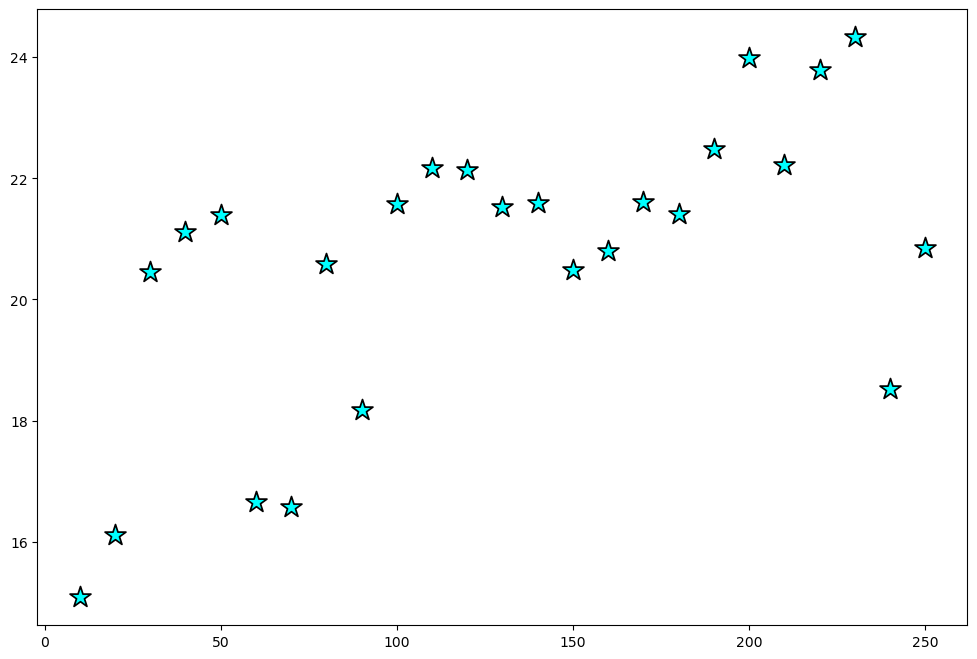

In [63]:
co2='fosterCO2'
df[co2]
fig, ax = plt.subplots(figsize=(12,8))
ax.scatter(x=df.index,y=df[co2], marker='*', facecolors=colours[i], edgecolors='black', linewidths=1.25, s=250,  label=f'{co2} ppm')

100
200
280
560
1120
2240
4480
fosterCO2
invalid literal for int() with base 10: 'fosterCO2'


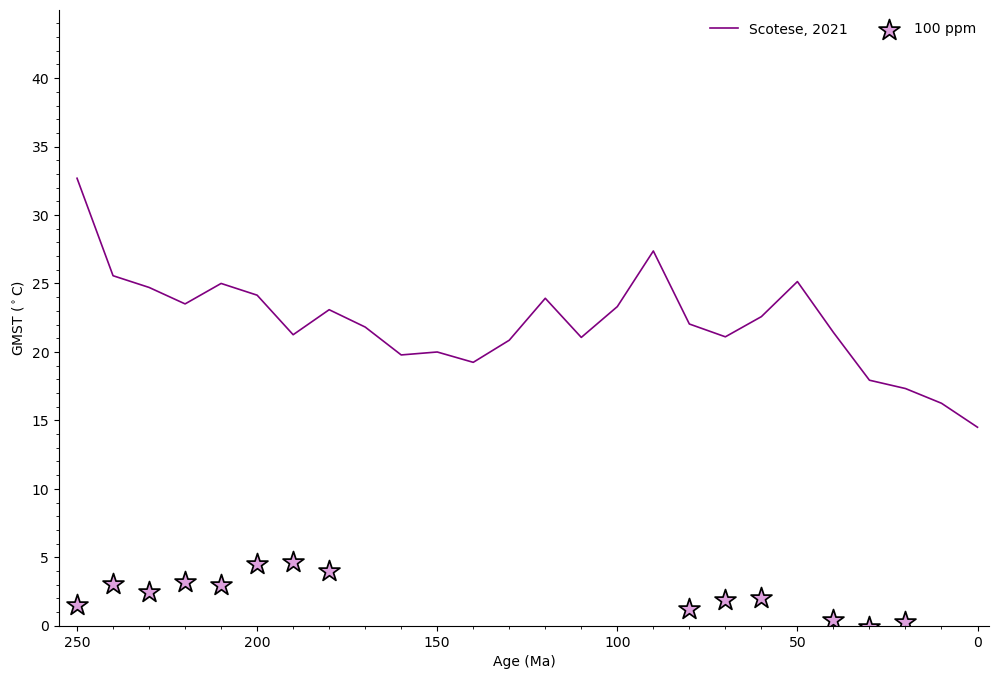

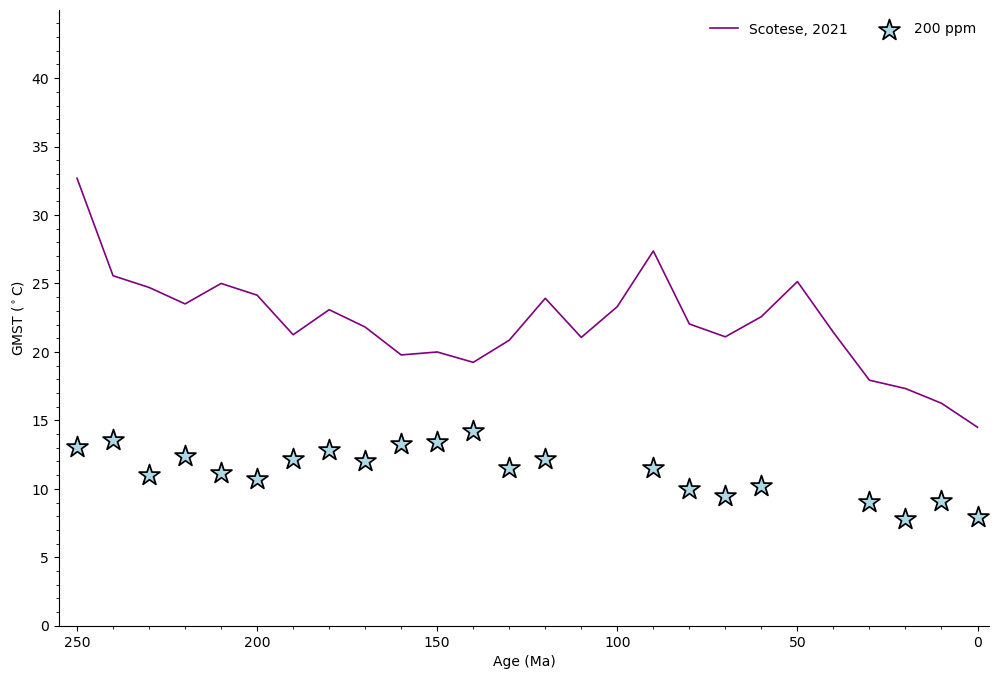

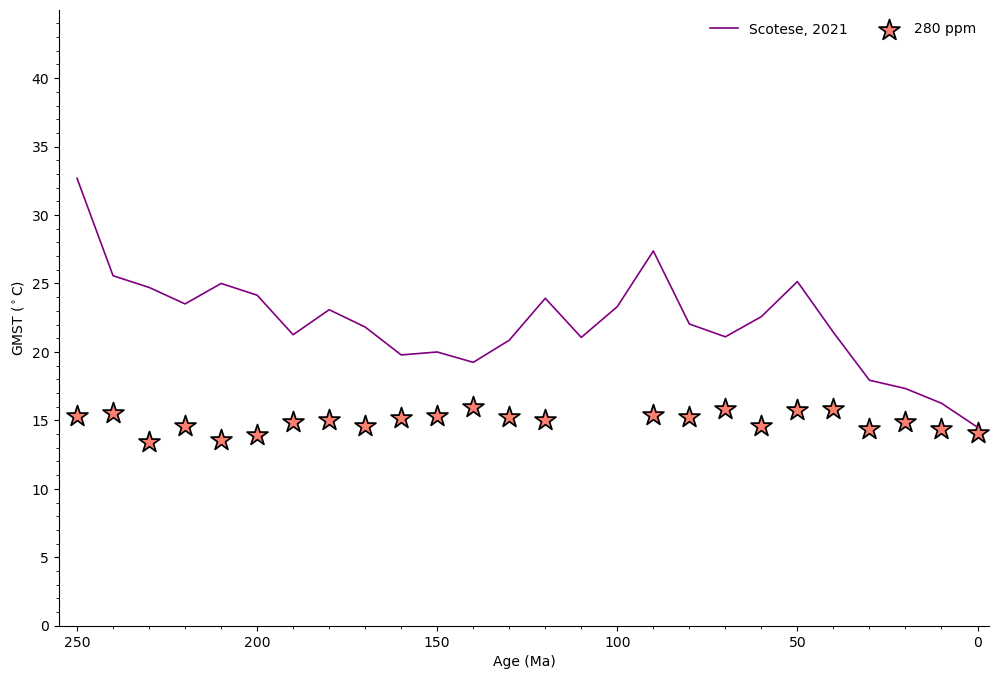

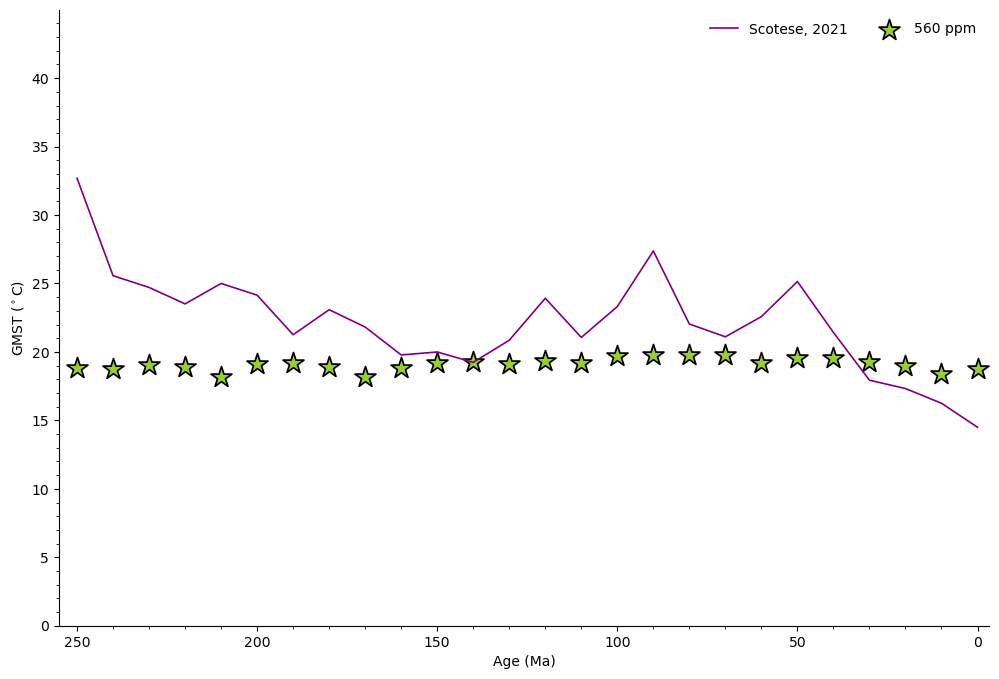

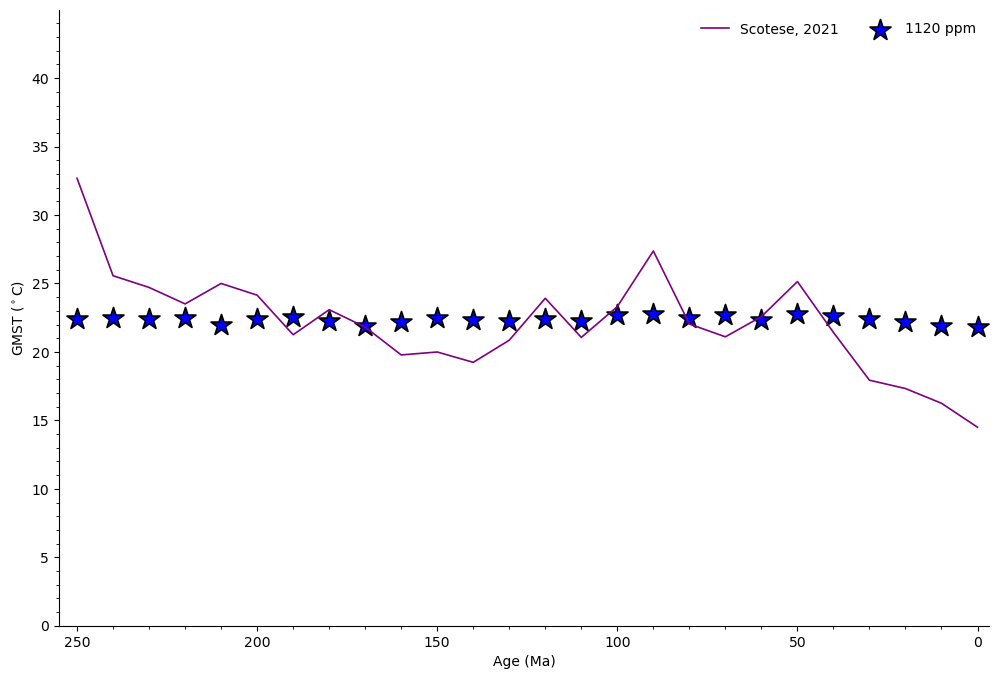

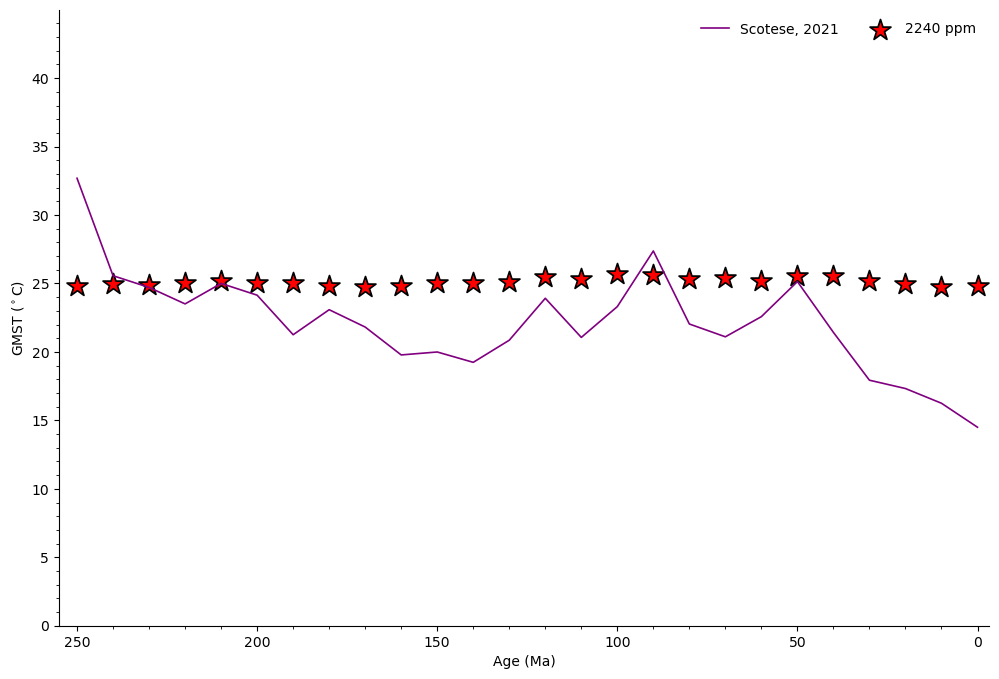

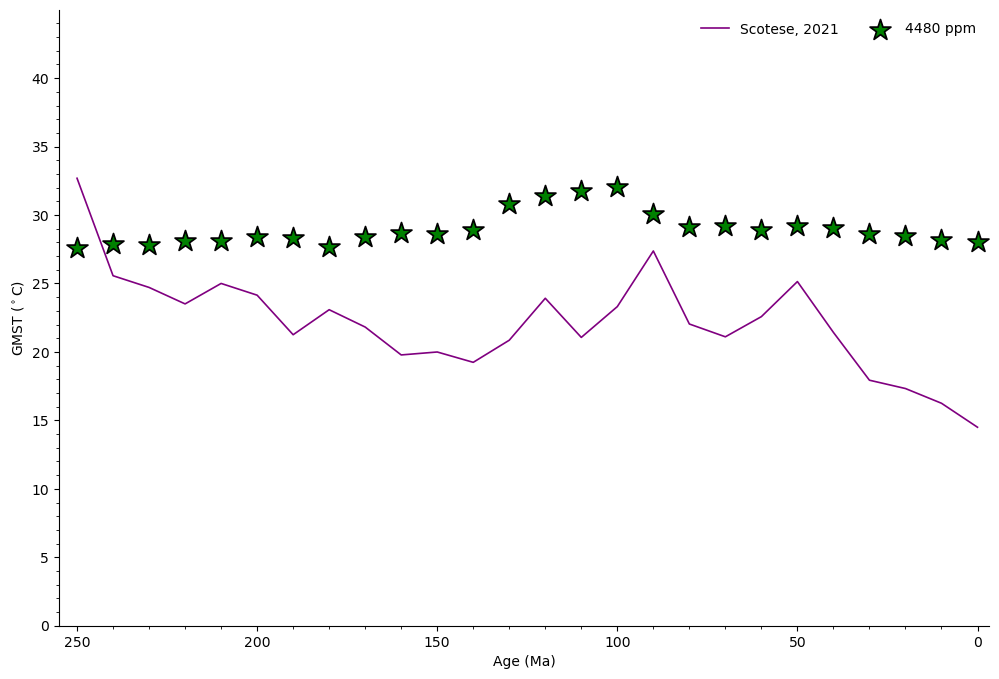

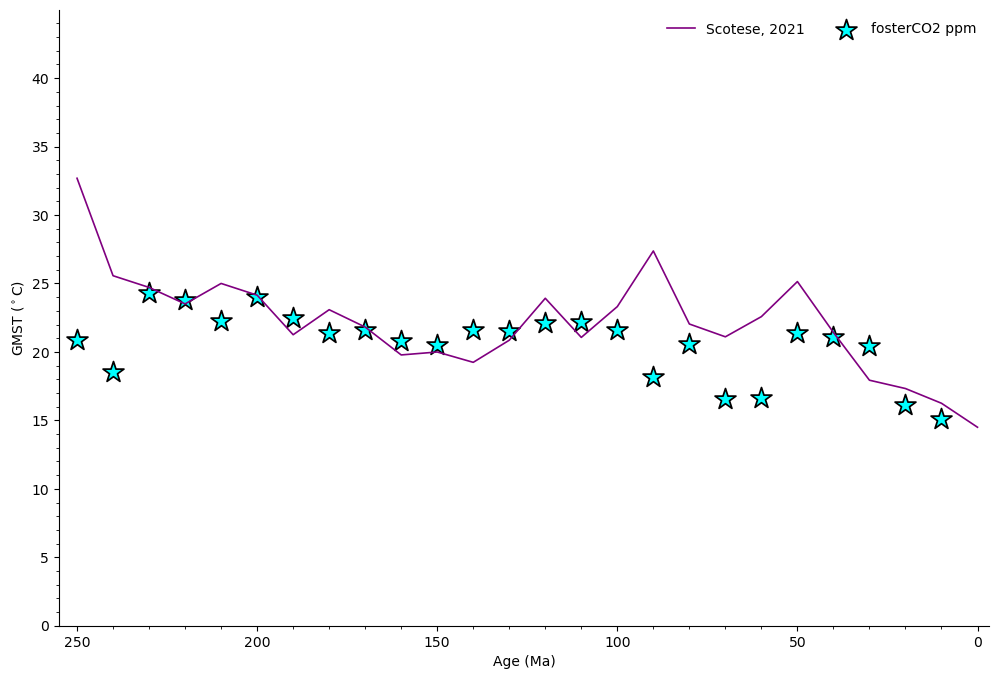

In [ ]:
outdir = 'co2_GMST'
if os.path.exists(outdir):
    shutil.rmtree(outdir)
os.makedirs(outdir)
i=0
for co2 in co2s:
    print(co2)
    fig, ax = plt.subplots(figsize=(12,8))

    # Set Y-axis limits
    ax.set_ylim(0, 45)
    ax.set_xlim(255,-3.2)

    # Add tick marks for the Y-axis
    ax.set_yticks(np.arange(0, 45, 5))
    ax.set_xticks(np.arange(0, 251, 50))

    ax.set_yticks(np.arange(0, 44.5, 1), minor=True)
    ax.set_xticks(np.arange(0, 251, 10), minor=True)

    # Customize grid appearance
    ax.xaxis.remove_overlapping_locs = False
    ax.yaxis.remove_overlapping_locs = False
    try:
        ax.plot(df.index, df['Scotese'], linewidth=1.2, color='purple', linestyle='-', label='Scotese, 2021')
        ax.scatter(x=df.index,y=df[co2], marker='*', facecolors=colours[i], edgecolors='black', linewidths=1.25, s=250,  label=f'{co2} ppm')
    except Exception as e:
       print(e)
       pass
    co2name = co2
    try:
        int(co2)
    except Exception as e:
        print(e)
        co2name = 'fosterCO2'
        
    ax.set_xlabel('Age (Ma)')
    ax.set_ylabel('GMST ($^\circ$C)')

    # Hide the right and top spines
    ax.spines[['right', 'top']].set_visible(False)

    ax.legend(loc='upper right', ncol=2, frameon=False)    
    plt.savefig(f'{outdir}/{co2name}_gmst_comparison.png')

    i+=1


In [65]:
import imageio
import re
### animation
def animation(directory,name='animation.gif'):
    def extract_starting_integer(s):
        match = re.match(r'(\d+)', s)
        return int(match.group(1)) if match else float('inf')

    images = []
    for im in sorted(os.listdir(directory), key=extract_starting_integer):
        print(im)
        if not im.endswith('png'):
            continue
        images.append(imageio.v2.imread(f'{directory}/{im}'))
    imageio.mimwrite(f'{directory}/{name}',images, duration=500)

animation(outdir)

100_gmst_comparison.png
200_gmst_comparison.png
280_gmst_comparison.png
560_gmst_comparison.png
1120_gmst_comparison.png
2240_gmst_comparison.png
4480_gmst_comparison.png
fosterCO2_gmst_comparison.png


In [66]:
# New dataframe that has how far each simulation is off the Scotese reconstruction
dfDiff = pd.DataFrame()
for co2 in co2s:
    dfDiff[co2] = np.abs(df['Scotese'] - df[co2])

# Create a dictionary that has the closest match model for each age
modelDict = {}
for age in dfDiff.index:
    closestModel = dfDiff.loc[age].idxmin()
    modelDict[age] = closestModel

modelDict # Dictionary of model to use that is closest to Scotese global temps for each age


{0.0: '280',
 10.0: 'fosterCO2',
 20.0: 'fosterCO2',
 30.0: '560',
 40.0: 'fosterCO2',
 50.0: '2240',
 60.0: '1120',
 70.0: '560',
 80.0: '1120',
 90.0: '2240',
 100.0: '1120',
 110.0: 'fosterCO2',
 120.0: '1120',
 130.0: 'fosterCO2',
 140.0: '560',
 150.0: 'fosterCO2',
 160.0: '560',
 170.0: '1120',
 180.0: '1120',
 190.0: 'fosterCO2',
 200.0: 'fosterCO2',
 210.0: '2240',
 220.0: 'fosterCO2',
 230.0: '2240',
 240.0: '2240',
 250.0: '4480'}

In [67]:
dfDiff

,100,200,280,560,1120,2240,4480,fosterCO2
Age,,,,,,,,
0.0,17.310900,6.524800,0.429300,4.265400,7.300800,10.292100,13.507700,NaN
10.0,19.202366,7.130166,1.893266,2.164234,5.636934,8.513534,11.923534,1.170866
20.0,17.027109,9.547409,2.451409,1.622391,4.824991,7.665191,11.116791,1.211609
30.0,18.020221,8.877621,3.536721,1.328679,4.500979,7.256679,10.677879,2.509979
40.0,21.025348,NaN,5.579548,1.875348,1.187252,4.109452,7.646552,0.312048
50.0,NaN,NaN,9.366829,5.588629,2.361729,0.406071,4.030771,3.745929
60.0,20.523230,12.368030,7.975330,3.380530,0.218630,2.606870,6.310870,5.922330
70.0,19.225140,11.644740,5.262440,1.359840,1.560660,4.308160,8.078160,4.534440
80.0,20.825926,12.082126,6.759426,2.282126,0.414574,3.264274,7.052474,1.451326


100
200
280
560
1120
2240
4480
fosterCO2


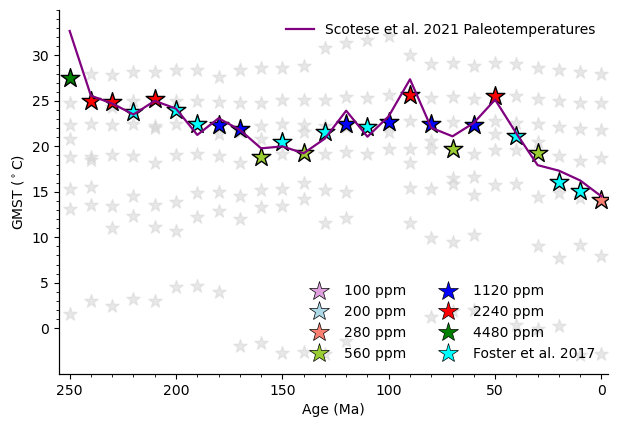

In [71]:
colours = ['plum','lightblue','salmon','yellowgreen','blue','red','green','cyan','orange','pink']
colourDict = {}
import matplotlib.lines as mlines
markers = []
labels = []
for i in range(len(co2s)):
    co2 = co2s[i]
    colour = colours[i]
    colourDict[co2] = colour

    # Legend
    marker = mlines.Line2D([], [], color=colour, marker='*', linestyle='None', markersize=15, markeredgewidth=0.5, markeredgecolor='black', label=f'{co2}')
    markers.append(marker)

    if co2 == 'fosterCO2':
        label = 'Foster et al. 2017'
    else:
        label = f'{co2} ppm'
    labels.append(label)
mm = 1/25.4  # mm in inches
fig, ax = plt.subplots(figsize=(180*mm,120*mm))

# Set Y-axis limits
ax.set_ylim(-5, 35)
ax.set_xlim(255,-3.2)

# Add tick marks for the Y-axis
ax.set_yticks(np.arange(0, 35, 5))
ax.set_xticks(np.arange(0, 251, 50))

ax.set_yticks(np.arange(0, 35.5, 1), minor=True)
ax.set_xticks(np.arange(0, 251, 10), minor=True)

# Customize grid appearance
ax.xaxis.remove_overlapping_locs = False
ax.yaxis.remove_overlapping_locs = False

ax.plot(df.index, df['Scotese'], linewidth=1.6, color='purple', linestyle='-', label='Scotese, 2021')
i=0
for i in range(len(co2s)):
    co2 = co2s[i]
    print(co2)
    try:
        ax.scatter(x=df.index,y=df[co2], marker='*', facecolors='lightgrey', edgecolors=None, linewidths=1, s=100, alpha=0.5)
    except:
        continue
    i+=1
for age in modelDict:
    co2 = modelDict[age]
    try:
        ax.scatter(x=age,y=df.loc[age,co2], marker='*', facecolors=colourDict[co2], edgecolors='black', linewidths=1, s=200)
    except:
        continue
    

ax.set_xlabel('Age (Ma)')
ax.set_ylabel('GMST ($^\circ$C)')

# Hide the right and top spines
ax.spines[['right', 'top']].set_visible(False)

ax.legend(markers, labels, loc='best', ncol=2, frameon=False)

ax2 = ax.twinx()
ax2.plot(np.NaN, np.NaN, linewidth=1.6, color='purple', linestyle='-', label='Scotese et al. 2021 Paleotemperatures')
ax2.get_yaxis().set_visible(False)
ax2.spines[['right', 'top']].set_visible(False)

ax2.legend(frameon=False)

plt.savefig(f'gmst_comparison_optimum.png', dpi=300)









In [69]:
markers